# 05 — Modélisation Risques (Modèle C)
## Jour 2, sous-étape 2e — Baseline régression logistique

Cible : risque de retard, grain Localité (55 lignes).

**Ce notebook commence par une reformulation de la cible**, nécessaire avant tout entraînement — voir section 1.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, accuracy_score, roc_curve)
import pickle

pd.set_option('display.max_columns', None)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Reformulation nécessaire de la cible « retard »

La cible envisagée au Jour 1 (décision D4, `reports/cadrage_jour1.md`) — l'écart entre l'avancement observé et une trajectoire théorique ancrée sur la date administrative de démarrage du marché — a été explicitement documentée comme limitée. Vérification avant tout entraînement :

In [2]:
t_avnt = pd.read_csv('../data/processed/table_avancement_departement_semaine_anonymisee.csv')
t_avnt = t_avnt[t_avnt['Departement']!='TOUTES']

print("Écart à la trajectoire théorique (D4) :")
print(t_avnt['Ecart_Avancement_Global_pct'].describe())
print()
seuil_plan = -15  # seuil initialement proposé dans le plan de mise en œuvre
print(f"Part des lignes 'à risque' avec le seuil du plan ({seuil_plan} points) : {(t_avnt['Ecart_Avancement_Global_pct'] < seuil_plan).mean()*100:.0f} %")

Écart à la trajectoire théorique (D4) :
count    80.000000
mean    -58.535709
std      17.519182
min     -90.430000
25%     -64.614959
50%     -52.923712
75%     -47.134024
max     -32.140000
Name: Ecart_Avancement_Global_pct, dtype: float64

Part des lignes 'à risque' avec le seuil du plan (-15 points) : 100 %


**Confirmé : la cible est dégénérée** (100 % des lignes seraient étiquetées « à risque »). Ce n'est pas surprenant — c'est exactement la conséquence de la limite déjà documentée en D4 (trajectoire ancrée sur nov. 2024, bien avant le début réel du suivi terrain en avril 2026). L'utiliser telle quelle produirait un classifieur qui n'a rien à apprendre.

**Cible alternative retenue pour ce baseline :** le **sous-avancement relatif par rapport aux pairs du même département** — une localité est étiquetée « à risque » si son avancement global est dans le quartile inférieur de son département. Cette définition :
- évite complètement le problème de la date d'ancrage du Gantt (D4) ;
- reste actionnable pour un chef de projet (« ces localités sont en retard par rapport aux autres du même département, à regarder en priorité ») ;
- donne une cible avec une vraie variance à apprendre.

**Limite assumée, à corriger au Jour 3 :** cette cible mesure une sous-performance *relative*, pas un retard *contractuel absolu*. La version « propre » (trajectoire théorique recalibrée sur le début réel des travaux physiques par département) reste prévue au Jour 3, pour comparaison.

In [3]:
df = pd.read_csv('../data/processed/table_pivot_anonymisee.csv')

# Table par localité (grain unique, 55 lignes)
loc = df.groupby(['ID_Localite','Localite','Departement','Commune','Statut']).agg(
    Avancement_pct=('Avancement_Global_Localite_pct','first'),
    Nb_Anomalies=('Nb_Anomalies_Signalees','first'),
    Nb_Lignes_Materiel=('ID_Helper','count'),
    Prop_Non_Commencees=('Taux_Realisation', lambda x: (x==0).mean()),
).reset_index()

loc['Seuil_Dept_Q1'] = loc.groupby('Departement')['Avancement_pct'].transform(lambda x: x.quantile(0.25))
loc['En_Retard_Relatif'] = (loc['Avancement_pct'] <= loc['Seuil_Dept_Q1']).astype(int)

print("Balance de la cible :")
print(loc['En_Retard_Relatif'].value_counts())
print()
print("Répartition par département :")
print(loc.groupby('Departement')['En_Retard_Relatif'].agg(['sum','count']))

Balance de la cible :
En_Retard_Relatif
0    40
1    15
Name: count, dtype: int64

Répartition par département :
             sum  count
Departement            
ALIBORI        3     11
ATACORA        4     14
BORGOU         4     16
DONGA          4     14


**27 % de localités « à risque » (15/55)**, réparties sur les 4 départements (3 à 4 chacun) — une balance bien plus exploitable que les 52/55 « En Cours » du `Statut` brut.

## 2. Variables explicatives — choix restreint et justifié

Avec seulement 55 lignes, le baseline doit rester minimal (cohérent avec le principe déjà appliqué au Modèle A et B : simplicité avant complexité). Deux exclusions volontaires :

- **`Avancement_pct` n'est pas une feature** : c'est la variable dont la cible est directement dérivée — l'inclure serait une fuite de données triviale.
- **`Departement` n'est pas une feature** : la cible est définie *relativement au département* (quartile intra-département) — l'inclure permettrait au modèle d'apprendre des effets de bord artificiels plutôt qu'un vrai signal.

Variables retenues : `Nb_Anomalies` (anomalies terrain signalées), `Prop_Non_Commencees` (part des lignes matériel de la localité à 0 %), `Nb_Lignes_Materiel` (taille/complexité de la localité).

In [4]:
features = ['Nb_Anomalies', 'Nb_Lignes_Materiel', 'Prop_Non_Commencees']
X = loc[features]
y = loc['En_Retard_Relatif']

pipe = Pipeline([('scale', StandardScaler()), ('model', LogisticRegression(class_weight='balanced', random_state=42))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pred = cross_val_predict(pipe, X, y, cv=cv)
proba = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:,1]

## 3. Évaluation — jamais l'accuracy seule

Principe déjà appliqué sur le projet précédent (maintenance prédictive) et rappelé dans le guide de référence (section 3.3) : sur une classe minoritaire, l'accuracy est trompeuse. Priorité à la matrice de confusion, Precision/Recall/F1, et ROC-AUC.

In [5]:
cm = confusion_matrix(y, pred)
print("Matrice de confusion (agrégée sur 5 plis) :")
print(pd.DataFrame(cm, index=['Réel: Non','Réel: Oui'], columns=['Prédit: Non','Prédit: Oui']))
print()
print(f"Accuracy   : {accuracy_score(y, pred):.3f}  (indicatif seulement — {(y==0).mean():.3f} en prédisant toujours 'Non')")
print(f"Precision  : {precision_score(y, pred):.3f}")
print(f"Recall     : {recall_score(y, pred):.3f}")
print(f"F1-score   : {f1_score(y, pred):.3f}")
print(f"ROC-AUC    : {roc_auc_score(y, proba):.3f}")
print(f"PR-AUC     : {average_precision_score(y, proba):.3f}")

Matrice de confusion (agrégée sur 5 plis) :
           Prédit: Non  Prédit: Oui
Réel: Non           25           15
Réel: Oui            4           11

Accuracy   : 0.655  (indicatif seulement — 0.727 en prédisant toujours 'Non')
Precision  : 0.423
Recall     : 0.733
F1-score   : 0.537
ROC-AUC    : 0.740
PR-AUC     : 0.501


**Constat :** avec `class_weight='balanced'` et un seuil par défaut (0,5), le modèle détecte **11 des 15 localités réellement à risque** (Recall = 0,73), au prix de 15 fausses alertes (Precision = 0,42). ROC-AUC = 0,74 — un signal net au-dessus du hasard (0,5), pour un baseline à 3 variables sur 55 observations.

Ce compromis (favoriser le Recall) est cohérent avec l'usage visé : pour un signal d'alerte destiné à prioriser des visites de terrain, mieux vaut sur-signaler que manquer une localité réellement en difficulté — exactement la logique déjà appliquée sur le projet de maintenance prédictive (seuil optimisé plutôt que 0,5 par défaut). L'optimisation fine du seuil est repoussée au Jour 3, une fois le modèle retenu comparé à ce baseline.

## 4. Interprétabilité — les coefficients ont-ils un sens physique ?

Réflexe déjà appliqué tout au long de ce projet (cf. guide, section 3.5) : un modèle interprétable doit être vérifié, pas seulement mesuré.

In [6]:
pipe_final = Pipeline([('scale', StandardScaler()), ('model', LogisticRegression(class_weight='balanced', random_state=42))])
pipe_final.fit(X, y)
coefs = pd.Series(pipe_final.named_steps['model'].coef_[0], index=features).sort_values()
coefs

Nb_Anomalies          -0.740177
Nb_Lignes_Materiel     0.117632
Prop_Non_Commencees    1.024555
dtype: float64

**Constat, avec un lien direct vers l'EDA du matin (2a) :**

- **`Prop_Non_Commencees` (+1,02)** : plus une localité a de lignes matériel non démarrées, plus elle est susceptible d'être en retard relatif. Intuitif, sans surprise.
- **`Nb_Anomalies` (-0,74, signe négatif)** : avoir eu une anomalie signalée est associé à un **risque plus faible**, pas plus élevé. Ce n'est pas une erreur — c'est exactement cohérent avec le constat de la section 2a de l'EDA (`02_eda.ipynb`) : les anomalies sont plus souvent détectées sur des localités déjà bien avancées (on ne remarque un écart qu'en vérifiant un travail proche de la fin). Le modèle a appris la même relation que celle déjà observée à l'œil en EDA — un bon signal de confiance, pas un artefact.
- **`Nb_Lignes_Materiel` (+0,12, faible)** : effet marginal, les localités plus complexes (plus de lignes matériel) sont légèrement plus à risque.

Cette cohérence entre EDA et coefficients du modèle est précisément ce que la vérification d'interprétabilité est censée révéler.

## 5. Visualisations

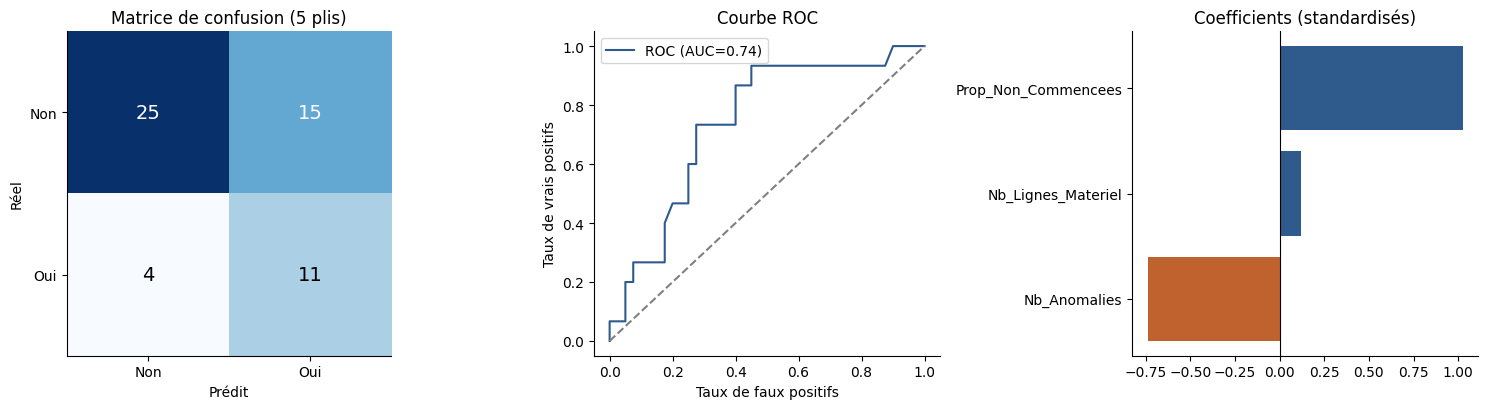

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Non','Oui'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Non','Oui'])
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion (5 plis)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                      color='white' if cm[i,j]>cm.max()/2 else 'black')

fpr, tpr, _ = roc_curve(y, proba)
auc = roc_auc_score(y, proba)
axes[1].plot(fpr, tpr, color='#2E5A8C', label=f'ROC (AUC={auc:.2f})')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_xlabel('Taux de faux positifs'); axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC'); axes[1].legend()

axes[2].barh(coefs.index, coefs.values, color=['#C0622D' if v<0 else '#2E5A8C' for v in coefs.values])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coefficients (standardisés)')

plt.tight_layout()
plt.show()

## 6. Sauvegarde du pipeline

In [8]:
import os
os.makedirs('../models', exist_ok=True)
with open('../models/model_C_risque_logreg.pkl', 'wb') as f:
    pickle.dump(pipe_final, f)
print("Sauvegardé : models/model_C_risque_logreg.pkl")

Sauvegardé : models/model_C_risque_logreg.pkl


## 7. Bilan de la sous-étape 2e — et du Jour 2 dans son ensemble

| Point vérifié | Résultat |
|---|---|
| Cible D4 (écart trajectoire théorique) | Confirmée dégénérée (100 % positif) — non utilisée telle quelle |
| Cible alternative (sous-avancement relatif intra-département) | Balance exploitable (27 % positif), variance réelle |
| Fuite de données | Évitée (`Avancement_pct` et `Departement` exclus des features) |
| Performance | Recall 0,73, ROC-AUC 0,74 — net au-dessus du hasard |
| Cohérence physique des coefficients | Confirmée, et reliée explicitement au constat de l'EDA (2a) sur les anomalies |
| Pipeline sauvegardé | `models/model_C_risque_logreg.pkl` |

### Bilan du Jour 2

Les 3 baselines chiffrées prévues par la feuille de route sont livrées : régression Ridge stratifiée par unité (A, R²=0,71/0,47), tendance linéaire par département (B, MAE=4,25 pts à S+4), régression logistique sur cible relative (C, ROC-AUC=0,74). Deux bugs de données réels ont été détectés et corrigés en cours de route (jointure anomalies au grain erroné en 2a, cumul négatif par saisie aberrante en 2b) — la donnée est maintenant plus fiable qu'au sortir du Jour 1.

**Prochaine étape (Jour 3, à valider) :** modèles retenus (Gradient Boosting × 2, classifieur avec seuil optimisé), validation croisée temporelle, comparaison chiffrée aux 3 baselines — et, pour le Modèle C, un second essai avec la trajectoire théorique corrigée (ancrée sur le début réel des travaux physiques) pour comparer les deux définitions de la cible.